# Forecast de ingresos de peajes a nivel nacional para el 2025 y 2026 - CRISP-DM

## 01. Entendimiento del Negocio

### Objetivo

El objetivo del Actual Análisis es predecir el flujo vehicular por mes de diferentes tipos de carros, en los peajes del perú.

### KPIS de existo

Lograr construir un modelo que prediga el flujo vehicular con una exactitud mayor al 60%.

### Fuente de datos

Fuente: https://www.datosabiertos.gob.pe/dataset/flujo-vehicular-registrado-en-las-unidades-de-peaje-de-la-red-vial-nacional-2014-%E2%80%93-2025-ii

Fuente de PBI: https://estadisticas.bcrp.gob.pe/estadisticas/series/mensuales/resultados/PN01770AM/html

Dias feriados y no laborales: Consolidado en un CSV:

#### Fuente:
* Decreto Legislativo Nº 713: Ley fundamental que consolida los descansos remunerados de los trabajadores sujetos al régimen laboral de la actividad privada (Feriados).
* Leyes Modificatorias (Congreso de la República):
* Ley Nº 31381 (2021): Incorpora el 9 de diciembre.
* Ley Nº 31530 (2022): Incorpora el 6 de agosto.
* Ley Nº 31822 (2023): Incorpora el 23 de julio.
* Ley Nº 31751 (2023): Incorpora el 7 de junio.
* Decretos Supremos de la PCM (Presidencia del Consejo de Ministros): Normas publicadas anualmente en el Diario Oficial El Peruano que designan los días no laborables específicos (ej. DS 011-2024-PCM para 2024-2025, DS 151-2022-PCM, etc.).
* Archivo Digital del Diario Oficial El Peruano: Sección de Normas Legales para verificar días no laborables extraordinarios (como los de la visita del Papa en 2018 o las cumbres APEC de 2016 y 2024).

## 02. Entendimiento del Dato

### Pasos

1. Cargamos los datasets

    * Tratamos los datasets
    * Creamos la llaves de cada uno 
    * Consolidamos en 1 solo dataset los datasets.
    * Limpiamos las columnas no importantes a simple vista

2. Ver de manera general ala cantidad de datos (info)
3. Ver una descripción estadistica de los datos (describe)
4. Vemos los porcentajes de nulos
5. Separamos las columnas numéricas (solo las necesarias)
6. Separamos las columnas categóricas

In [51]:
# Cargamos los datos
import pandas as pd

# Configuraciones del notebbok
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

data_base = pd.read_csv('../Data/Row/Flujo vehicular registrado en peajes_2014-2025_II.csv', encoding='latin-1')
data_pbi = pd.read_excel('../Data/Row/PBI_Mensual_201401_202508.xlsx', sheet_name='Mensuales')
data_feriados = pd.read_csv('../Data/Row/Feriados_No_Laborables_Fines_de_semana.csv')

# Mostramos los datos
data_base.head()

,ID,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,NOMBRE_PEAJE,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO
0,0,Concesionado,22PE5NACS1,San Martín,Aguas Claras,2099,8070.0,0,2586.0,2374.0,720.0,315.0,3512.0,8.0,10169,328.0,9515,306.9,19684,635.0,2014,1,201401
1,1,Concesionado,04PE1SCAM1,Arequipa,Camaná,0,24644.0,0,6502.0,4622.0,1654.0,3028.0,8711.0,213.0,24644,795.0,24730,797.7,49374,1592.7,2014,1,201401
2,2,Concesionado,21PE3SCRO1,Puno,Caracoto,33643,82139.0,5797,17981.0,5307.0,1150.0,1737.0,5342.0,12.0,115782,3734.9,37326,1204.1,153108,4939.0,2014,1,201401
3,3,Concesionado,12PE3NCRA1,Junín,Casaracra-Concesión,10,46944.0,0,16981.0,18585.0,4463.0,3058.0,19400.0,135.0,46954,1514.6,62622,2020.1,109576,3534.7,2014,1,201401
4,4,Concesionado,08PE3SCSC1,Cusco,Ccasacancha (Huillque),0,23831.0,0,4709.0,3941.0,447.0,769.0,3945.0,95.0,23831,768.7,13906,448.6,37737,1217.3,2014,1,201401


In [52]:
data_pbi.head()

,Mes,PBI
0,Ene14,136.331425
1,Feb14,136.032830
2,Mar14,144.308470
3,Abr14,146.068668
4,May14,148.341447


In [53]:
# Tratamos el dataset PBI
data_pbi['Mes'].unique()

dic_mes = {'Ene':1, 'Feb':2, 'Mar':3, 'Abr':4, 'May':5, 'Jun':6, 'Jul':7, 'Ago':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dic':12}
dic_anio = {'14':'2014', '15':'2015', '16':'2016', '17':'2017', '18':'2018', '19':'2019', '20':'2020', '21':'2021', '22':'2022', '23':'2023', '24':'2024', '25':'2025'}
data_pbi['Mes_str'] = data_pbi['Mes'].apply(lambda x: dic_mes[x[:3]])
data_pbi['Anio_str'] = data_pbi['Mes'].apply(lambda x: dic_anio[x[3:]])

In [62]:
data_pbi.head()

,Mes,PBI,Mes_str,Anio_str,llave
0,Ene14,136.331425,1,2014,20141
1,Feb14,136.032830,2,2014,20142
2,Mar14,144.308470,3,2014,20143
3,Abr14,146.068668,4,2014,20144
4,May14,148.341447,5,2014,20145


In [55]:
data_feriados.head()

,Anio,Mes,Feriados,No_Laborables_Fuera_de_Feriado,Fines_de_Semana
0,2014,1,1,1,8
1,2014,2,0,0,8
2,2014,3,0,0,10
3,2014,4,2,0,8
4,2014,5,1,0,9


In [56]:
# Creamos las llaves
data_base['llave'] = data_base['ANIO'].astype(str) + data_base['MES'].astype(str)
data_pbi['llave'] = data_pbi['Anio_str'].astype(str) + data_pbi['Mes_str'].astype(str)
data_feriados['llave'] = data_feriados['Anio'].astype(str) + data_feriados['Mes'].astype(str)

In [57]:
# juntamos la información
data_merge_01 = data_base.merge(data_pbi, on='llave', how='left')
data_total = data_merge_01.merge(data_feriados, on='llave', how='left')

In [58]:
data_total.head()

,ID,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,NOMBRE_PEAJE,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO,llave,Mes_x,PBI,Mes_str,Anio_str,Anio,Mes_y,Feriados,No_Laborables_Fuera_de_Feriado,Fines_de_Semana
0,0,Concesionado,22PE5NACS1,San Martín,Aguas Claras,2099,8070.0,0,2586.0,2374.0,720.0,315.0,3512.0,8.0,10169,328.0,9515,306.9,19684,635.0,2014,1,201401,20141,Ene14,136.331425,1,2014,2014,1,1,1,8
1,1,Concesionado,04PE1SCAM1,Arequipa,Camaná,0,24644.0,0,6502.0,4622.0,1654.0,3028.0,8711.0,213.0,24644,795.0,24730,797.7,49374,1592.7,2014,1,201401,20141,Ene14,136.331425,1,2014,2014,1,1,1,8
2,2,Concesionado,21PE3SCRO1,Puno,Caracoto,33643,82139.0,5797,17981.0,5307.0,1150.0,1737.0,5342.0,12.0,115782,3734.9,37326,1204.1,153108,4939.0,2014,1,201401,20141,Ene14,136.331425,1,2014,2014,1,1,1,8
3,3,Concesionado,12PE3NCRA1,Junín,Casaracra-Concesión,10,46944.0,0,16981.0,18585.0,4463.0,3058.0,19400.0,135.0,46954,1514.6,62622,2020.1,109576,3534.7,2014,1,201401,20141,Ene14,136.331425,1,2014,2014,1,1,1,8
4,4,Concesionado,08PE3SCSC1,Cusco,Ccasacancha (Huillque),0,23831.0,0,4709.0,3941.0,447.0,769.0,3945.0,95.0,23831,768.7,13906,448.6,37737,1217.3,2014,1,201401,20141,Ene14,136.331425,1,2014,2014,1,1,1,8


In [73]:
# Eliminamos columnas no significativas o innecesarias del merge
data_total_f = data_total.drop(columns=['Mes_str', 'Anio_str', 'Mes_y', 'ID', 'Mes_x', 'Anio', 'NOMBRE_PEAJE'])

In [74]:
# Analizamos la data consolidada
data_total_f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ADMINIST                        10781 non-null  object 
 1   CODIGO_PEAJE                    10781 non-null  object 
 2   DEPARTAMENTO                    10781 non-null  object 
 3   VEH_LIGEROS_TAR_DIF             10781 non-null  int64  
 4   VEH_LIGEROS_AUTOMOVILES         10768 non-null  float64
 5   VEH_PESADOS_TAR_DIF             10781 non-null  int64  
 6   VEH_PESADOS__2E                 10773 non-null  float64
 7   VEH_PESADOS_3E                  10773 non-null  float64
 8   VEH_PESADOS_4E                  10773 non-null  float64
 9   VEH_PESADOS_5E                  10773 non-null  float64
 10  VEH_PESADOS_6E                  10773 non-null  float64
 11  VEH_PESADOS_7E                  10773 non-null  float64
 12  VEH_LIGEROS_TOTAL               

In [75]:
data_total_f.describe()

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO,PBI,Feriados,No_Laborables_Fuera_de_Feriado,Fines_de_Semana
count,10781.000000,10768.000000,10781.000000,10773.000000,10773.000000,10773.000000,10773.000000,10773.000000,10773.000000,10781.000000,10781.000000,10781.000000,10781.000000,1.078100e+04,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000
mean,1896.093034,44374.207467,817.151841,8630.367586,7666.940685,1943.485287,2289.993874,11708.790495,162.748538,46216.792969,1521.112485,33195.434283,1092.216548,7.941223e+04,2613.362768,2019.339208,6.370281,201940.291068,166.034893,1.067804,0.463593,8.688990
std,6297.010934,66000.775351,2710.769041,10942.912132,9845.497573,2608.109405,3324.176873,16266.681390,391.491280,67003.821544,2206.051192,41535.153871,1364.473182,9.904596e+04,3258.058113,3.320685,3.448075,331.862137,15.938679,0.802907,0.790420,0.788259
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2014.000000,1.000000,201401.000000,102.971603,0.000000,0.000000,8.000000
25%,0.000000,11284.000000,0.000000,2125.000000,1300.000000,309.000000,269.000000,1728.000000,12.000000,11870.000000,393.600000,7393.000000,244.200000,2.241400e+04,739.000000,2016.000000,3.000000,201612.000000,155.609029,0.000000,0.000000,8.000000
50%,0.000000,23460.500000,0.000000,4218.000000,3573.000000,807.000000,808.000000,4172.000000,46.000000,24623.000000,811.100000,15964.000000,524.100000,4.208300e+04,1390.200000,2019.000000,6.000000,201911.000000,167.122086,1.000000,0.000000,8.000000
75%,376.000000,47658.250000,0.000000,10589.000000,8678.000000,2486.000000,2817.000000,15900.000000,192.000000,50025.000000,1644.200000,40611.000000,1335.700000,9.940700e+04,3282.100000,2022.000000,9.000000,202209.000000,177.880969,2.000000,1.000000,9.000000
max,71734.000000,796486.000000,38818.000000,73590.000000,78943.000000,25137.000000,25361.000000,99895.000000,21799.000000,796486.000000,27914.100000,241058.000000,8440.800000,1.037544e+06,35023.400000,2025.000000,12.000000,202506.000000,205.582414,3.000000,4.000000,10.000000


In [76]:
(data_total_f.isnull().sum()/data_total_f.count())*100 # vemos el porcentaje de nulos que tiene la información.

ADMINIST                          0.000000
CODIGO_PEAJE                      0.000000
DEPARTAMENTO                      0.000000
VEH_LIGEROS_TAR_DIF               0.000000
VEH_LIGEROS_AUTOMOVILES           0.120728
VEH_PESADOS_TAR_DIF               0.000000
VEH_PESADOS__2E                   0.074260
VEH_PESADOS_3E                    0.074260
VEH_PESADOS_4E                    0.074260
VEH_PESADOS_5E                    0.074260
VEH_PESADOS_6E                    0.074260
VEH_PESADOS_7E                    0.074260
VEH_LIGEROS_TOTAL                 0.000000
VEH_LIGEROS_IMD                   0.000000
VEH_PESADOS_TOTAL                 0.000000
VEH_PESADOS_IMD                   0.000000
VEH_TOTAL                         0.000000
VEH_IMD                           0.000000
ANIO                              0.000000
MES                               0.000000
PERIODO                           0.000000
llave                             0.000000
PBI                               0.000000
Feriados   

In [77]:
# Separamos variables numéricas de categóricas.
data_row = data_total_f.copy()

col_df_num = data_row.select_dtypes(include=['number', 'float64', 'int64']).columns
col_df_cat = data_row.select_dtypes(include=['object', 'category']).columns

In [78]:
col_df_num

Index(['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS_TAR_DIF',
       'VEH_PESADOS__2E', 'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E',
       'VEH_PESADOS_6E', 'VEH_PESADOS_7E', 'VEH_LIGEROS_TOTAL',
       'VEH_LIGEROS_IMD', 'VEH_PESADOS_TOTAL', 'VEH_PESADOS_IMD', 'VEH_TOTAL',
       'VEH_IMD', 'ANIO', 'MES', 'PERIODO', 'PBI', 'Feriados',
       'No_Laborables_Fuera_de_Feriado', 'Fines_de_Semana'],
      dtype='object')

In [81]:
col_df_cat

Index(['ADMINIST', 'CODIGO_PEAJE', 'DEPARTAMENTO', 'llave'], dtype='object')

In [82]:
df_processed = data_row.copy()
df_processed['PERIODO'] = pd.to_datetime(data_row['PERIODO'], format='%Y%m')

df_processed['CODIGO_PEAJE'].unique()

array(['22PE5NACS1', '04PE1SCAM1', '21PE3SCRO1', '12PE3NCRA1',
       '08PE3SCSC1', '13PE1NCMA1', '15PE1SCLA1', '20PE1NJCLS1',
       '13PE08CDS1', '15PE22CCA1', '20PE1NCBA1', '14PE04BOLS1',
       '04PE1SEFS1', '15PE1NEPS1', '15PE1NFZA1', '02PE1NHUY1',
       '11PE1SICA1', '18PE36ILO1', '11PE1SJAY1', '20PE02ALLA1',
       '21PE34BMNI1', '11PE30MNA1', '04PE34MRI1', '13PE10AMEO1',
       '14PE1NJMOC1', '18PE1SMTV1', '14PE1NMRE1', '22PE5NMYB1',
       '13PE1NPGA1', '20PE02PAI1', '18PE36APCL1', '05PE30APGR1',
       '03PE30APPR1', '04PE34APTI1', '01PE08CPRS1', '03PE30APRH1',
       '20PE1NPSA1', '17PE30CPNN1', '06PE3NPPU1', '22PE5NBPGO1',
       '12PE3SQLA1', '21PE34BSGB1', '17PE30CSLZ1', '21PE34ASLA1',
       '15PE1NASPY1', '23PE1STMS1', '04PE34AVYO1', '17PE30CUPO1',
       '01PE5NUTB1', '15PE1NVPY1', '02PE1NVSQ1', '13PE1NVIR1',
       '08PE3SACS1', '04PE1SATI1', '21PE3SAYV1', '24PE1NCCS1',
       '02PE3NCTC1', '12PE3SHUO1', '12PE22BCHO1', '14PE06ACUC1',
       '20PE1NTYL1', '21PE3SILV1'

In [83]:
data_row['PERIODO'].unique()

array([201401, 201402, 201403, 201404, 201405, 201406, 201407, 201408,
       201409, 201410, 201411, 201412, 201501, 201502, 201503, 201504,
       201505, 201506, 201507, 201508, 201509, 201510, 201511, 201512,
       201601, 201602, 201603, 201604, 201605, 201606, 201607, 201608,
       201609, 201610, 201611, 201612, 201701, 201702, 201703, 201704,
       201705, 201706, 201707, 201708, 201709, 201710, 201711, 201712,
       201801, 201802, 201803, 201804, 201805, 201806, 201807, 201808,
       201809, 201810, 201811, 201812, 201901, 201902, 201903, 201904,
       201905, 201906, 201907, 201908, 201909, 201910, 201911, 201912,
       202001, 202002, 202003, 202004, 202005, 202006, 202007, 202008,
       202009, 202010, 202011, 202012, 202101, 202102, 202103, 202104,
       202105, 202106, 202107, 202108, 202109, 202110, 202111, 202112,
       202201, 202202, 202203, 202204, 202205, 202206, 202207, 202208,
       202209, 202210, 202211, 202212, 202301, 202302, 202303, 202304,
      

In [84]:
data_row.columns

Index(['ADMINIST', 'CODIGO_PEAJE', 'DEPARTAMENTO', 'VEH_LIGEROS_TAR_DIF',
       'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS_TAR_DIF', 'VEH_PESADOS__2E',
       'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E',
       'VEH_PESADOS_7E', 'VEH_LIGEROS_TOTAL', 'VEH_LIGEROS_IMD',
       'VEH_PESADOS_TOTAL', 'VEH_PESADOS_IMD', 'VEH_TOTAL', 'VEH_IMD', 'ANIO',
       'MES', 'PERIODO', 'llave', 'PBI', 'Feriados',
       'No_Laborables_Fuera_de_Feriado', 'Fines_de_Semana'],
      dtype='object')

In [89]:
data_grp = data_row[['VEH_LIGEROS_TAR_DIF',
       'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS_TAR_DIF', 'VEH_PESADOS__2E',
       'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E',
       'VEH_PESADOS_7E', 'VEH_LIGEROS_TOTAL', 'VEH_LIGEROS_IMD',
       'VEH_PESADOS_TOTAL', 'VEH_PESADOS_IMD', 'VEH_TOTAL', 'VEH_IMD', 'ANIO',
       'MES', 'PERIODO', 'PBI', 'Feriados',
       'No_Laborables_Fuera_de_Feriado', 'Fines_de_Semana']].groupby(by = ['ANIO', 'MES', 'PERIODO'], as_index=False ).median()
data_grp.head()

,ANIO,MES,PERIODO,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,PBI,Feriados,No_Laborables_Fuera_de_Feriado,Fines_de_Semana
0,2014,1,201401,0.0,21977.0,0.0,5024.0,4198.0,975.0,892.0,4038.0,36.0,22582.0,728.5,17886.0,577.0,39872.0,1286.2,136.331425,1.0,1.0,8.0
1,2014,2,201402,0.0,20701.0,0.0,4598.0,4095.0,809.0,938.0,4269.0,39.0,20756.0,741.3,16496.0,589.1,36673.0,1309.8,136.032830,0.0,0.0,8.0
2,2014,3,201403,0.0,19034.0,0.0,4932.0,4261.0,818.0,985.0,4080.0,33.0,19348.0,624.1,16088.0,519.0,37347.0,1204.7,144.308470,0.0,0.0,10.0
3,2014,4,201404,0.0,18177.0,0.0,4722.0,4077.0,883.0,816.0,3818.0,36.0,18931.0,631.0,16238.0,541.3,37600.0,1253.3,146.068668,2.0,0.0,8.0
4,2014,5,201405,0.0,17245.0,0.0,4994.0,4184.0,893.0,962.0,4279.0,35.0,18342.0,591.7,17135.0,552.7,39681.0,1280.0,148.341447,1.0,0.0,9.0


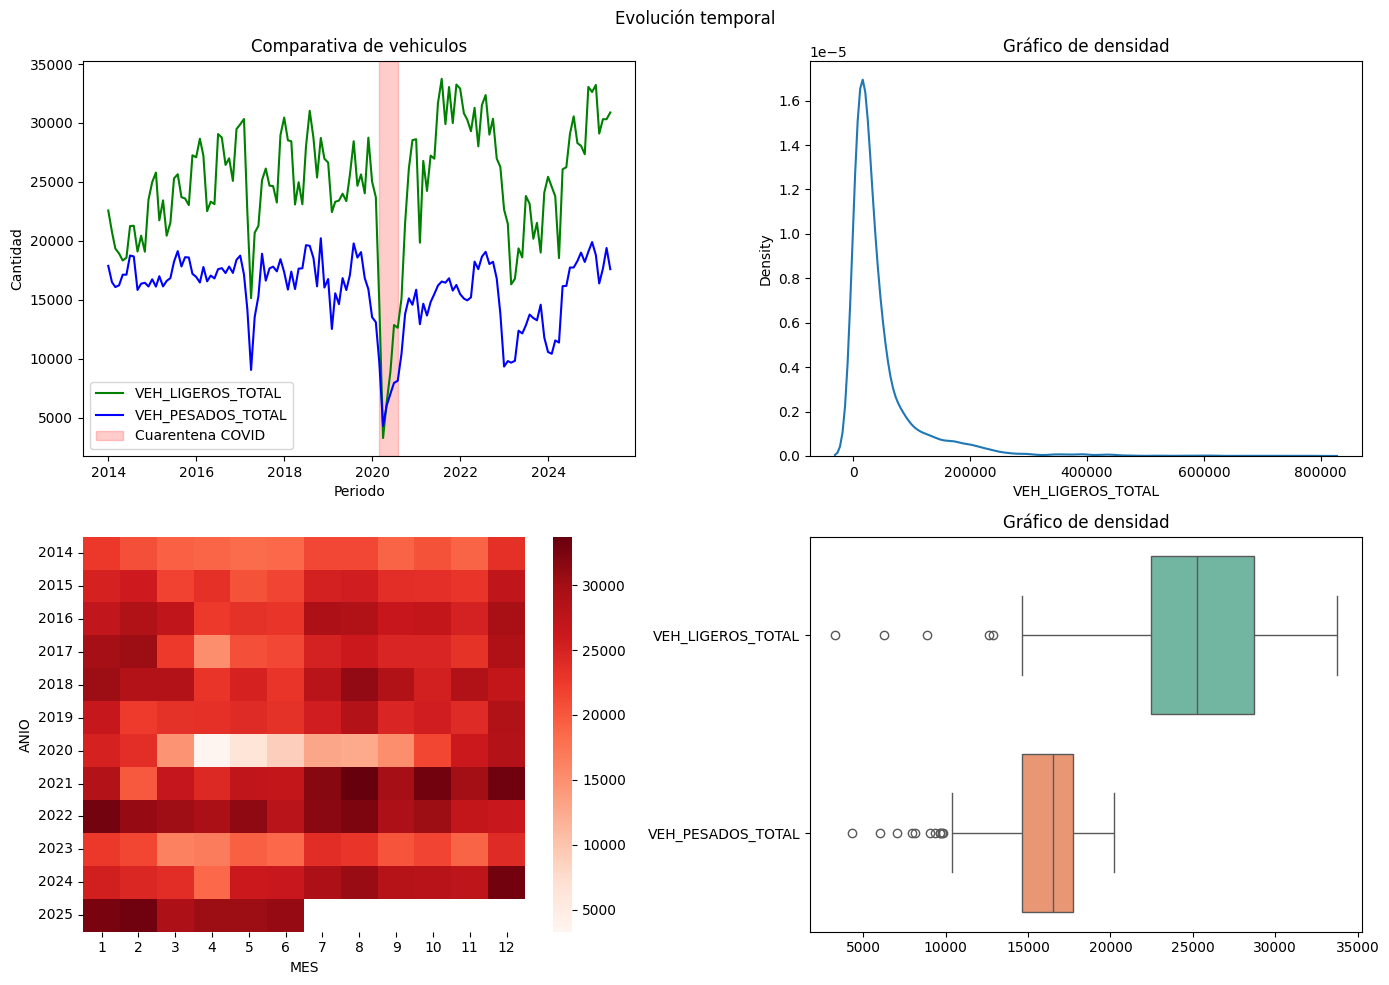

In [90]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

data_grp['FECHA_REAL'] = pd.to_datetime(data_grp['PERIODO'].astype(str), format='%Y%m')

col_num_var = [v for v in data_grp.columns if v not in {'ANIO', 'MES', 'PERIODO', 'VEH_LIGEROS_TOTAL', 'VEH_LIGEROS_IMD', 
                                                        'VEH_PESADOS_TOTAL', 'VEH_PESADOS_IMD', 'VEH_TOTAL', 'VEH_IMD'}]
num_vars = len(col_num_var)

variable_a_graficar = 'VEH_LIGEROS_TOTAL'
variable_a_graficar_2 = 'VEH_PESADOS_TOTAL'

fig, axes = plt.subplots(2, 2, figsize=( 14, 10))
fig.suptitle(f"Evolución temporal")

# Grafico 1 - Grafico de lineas
axes[0, 0].plot(data_grp['FECHA_REAL'], data_grp[variable_a_graficar], color='green', label=variable_a_graficar)
axes[0, 0].plot(data_grp['FECHA_REAL'], data_grp[variable_a_graficar_2], color='blue', label=variable_a_graficar_2)

# zona sombreada:
axes[0,0].axvspan('2020-03-01', '2020-08-01', color='red', alpha=0.2, label='Cuarentena COVID')

# Leyendas
axes[0, 0].set_title(f"Comparativa de vehiculos")
axes[0, 0].set_xlabel("Periodo")
axes[0, 0].set_ylabel("Cantidad")

axes[0,0].legend()

# Grafico 2 - Grafico de densidad
sns.kdeplot(data_row, x=data_row[variable_a_graficar], ax=axes[0,1] )
axes[0, 1].set_title(f"Gráfico de densidad")

# Grafico 3 - Grafico de calor
data_pivot = data_grp.pivot(index='ANIO', columns='MES', values=variable_a_graficar)
sns.heatmap(data_pivot, cmap='Reds', ax=axes[1,0])

# Grafico 4 - Gráfica de boxplot
sns.boxplot(data=data_grp[[variable_a_graficar, variable_a_graficar_2]], orient='h', ax=axes[1,1], palette='Set2')
axes[1, 1].set_title(f"Gráfico de densidad")

plt.tight_layout()


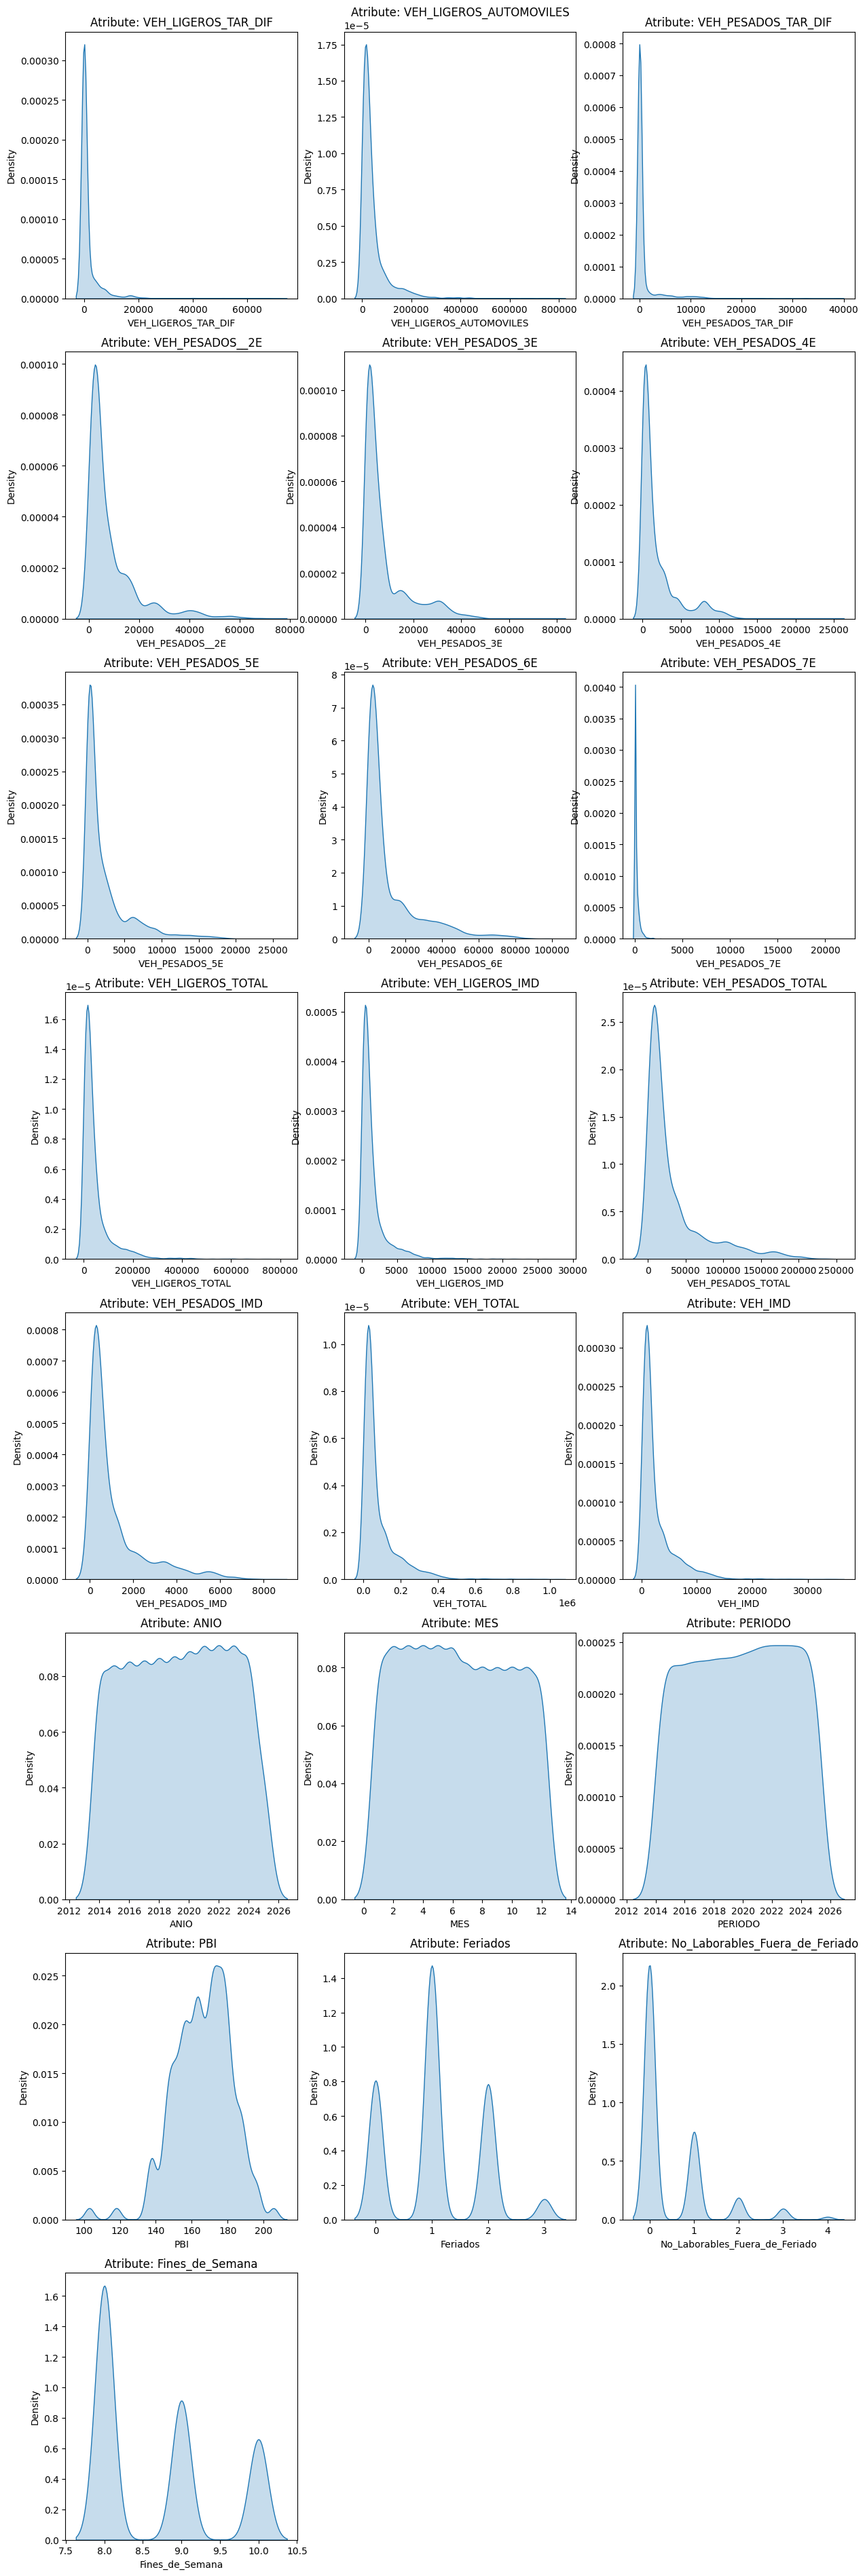

In [91]:
import seaborn as sns
import math

n_vars = len(col_df_num)
n_cols = 3

n_rows = math.ceil(n_vars / n_cols)

plt.figure(figsize=(15, 6*n_rows))

for i, atribute in enumerate(col_df_num):
    plt.subplot(n_rows, n_cols, i+1)
    sns.kdeplot(df_processed[atribute], fill=True)
    plt.title(f"Atribute: {atribute}")
    plt.xlabel(atribute)
    plt.ylabel('Density')


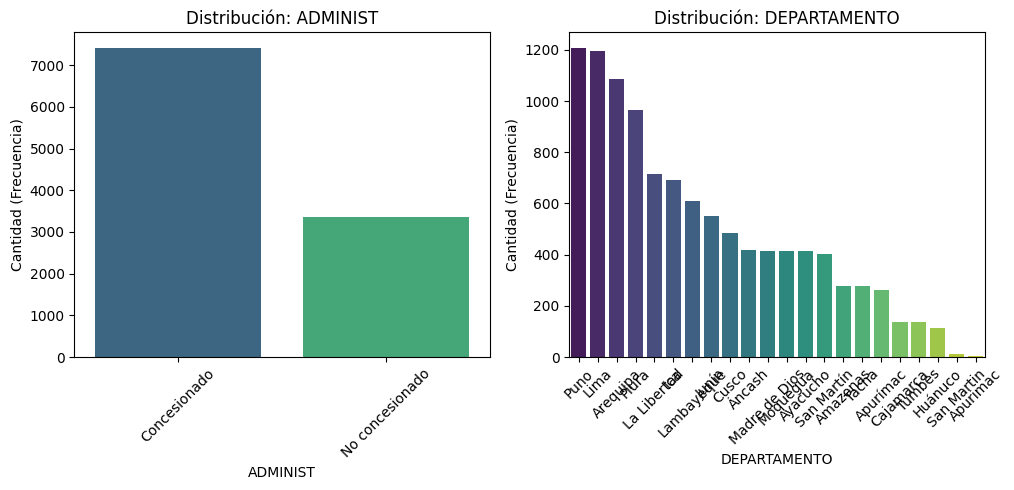

In [93]:

import matplotlib.pyplot as plt
import seaborn as sns
import math

# Asumiendo que tienes una lista de tus variables categóricas
# col_df_cat = ['Genero', 'Ciudad', 'Educacion', ...] 

col_df_cat_2 = [v for v in col_df_cat if v not in ('CODIGO_PEAJE', 'NOMBRE_PEAJE', 'llave')]

n_vars = len(col_df_cat_2)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols)

plt.figure(figsize=(15, 5 * n_rows)) # Aumenté un poco la altura por fila

for i, attribute in enumerate(col_df_cat_2):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # --- CAMBIO PRINCIPAL ---
    # Usamos countplot en lugar de kdeplot
    # order: Ordena las barras de la más frecuente a la menos frecuente
    sns.countplot(
        x=df_processed[attribute], 
        order=df_processed[attribute].value_counts().index,
        palette='viridis' # Opcional: añade color
    )
    # ------------------------
    
    plt.title(f"Distribución: {attribute}")
    plt.xlabel(attribute)
    plt.ylabel('Cantidad (Frecuencia)')
    
    # Rotamos 45 grados las etiquetas del eje X para que se lean bien
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()